In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('CRH','NFLX'), 
         ('CRH','MA'), 
         ('CRH','JNJ'), 
         ('TDG','NFLX'), 
         ('TDG', 'MA'),
         ('TDG', 'JNJ'), 
         ('NEM','NFLX'), 
         ('NEM', 'MA'), 
         ('NEM','JNJ')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, 

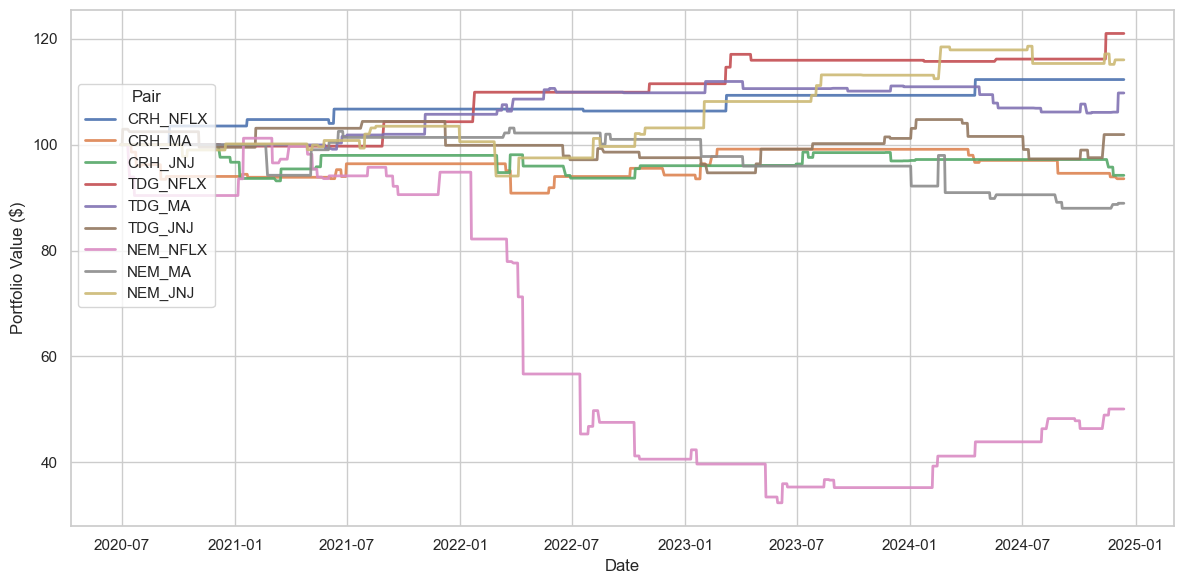

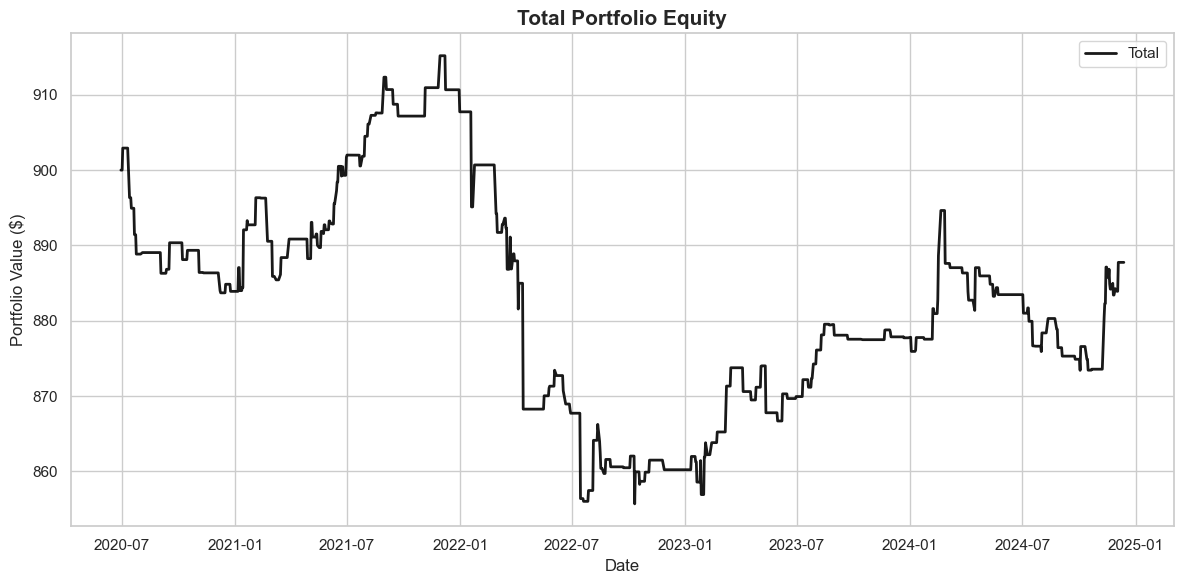

Summary
CRH_NFLX: Final Value = $112.30, Total Return = 12.30%, Trades = 7
CRH_MA: Final Value = $93.56, Total Return = -6.44%, Trades = 29
CRH_JNJ: Final Value = $94.20, Total Return = -5.80%, Trades = 26
TDG_NFLX: Final Value = $121.01, Total Return = 21.01%, Trades = 11
TDG_MA: Final Value = $109.76, Total Return = 9.76%, Trades = 32
TDG_JNJ: Final Value = $101.90, Total Return = 1.90%, Trades = 29
NEM_NFLX: Final Value = $50.06, Total Return = -49.94%, Trades = 46
NEM_MA: Final Value = $88.93, Total Return = -11.07%, Trades = 23
NEM_JNJ: Final Value = $116.02, Total Return = 16.02%, Trades = 32

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $887.75
Total Return:            -1.36%

Sharpe Ratios
CRH_NFLX: Sharpe Ratio = 0.93
CRH_MA: Sharpe Ratio = -0.31
CRH_JNJ: Sharpe Ratio = -0.30
TDG_NFLX: Sharpe Ratio = 1.01
TDG_MA: Sharpe Ratio = 0.61
TDG_JNJ: Sharpe Ratio = 0.11
NEM_NFLX: Sharpe Ratio = -0.56
NEM_MA: Sharpe Ratio = -0.35
NEM_JNJ: Sharpe 

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)